# A second format: ASEG-GDF

## GSPy workshop, part 2

Part 1 built a GS file from CSV files, where the header gives you column
names and nothing else. This notebook walks the same path for a Tempest AEM
survey stored in **ASEG-GDF2**, a format that carries its own column
definitions.

The interesting question is how much less work you have to do.

| | Section | Time |
|---|---|---|
| 1 | What is in the box? | 5 min |
| 2 | A template that fills itself in | 10 min |
| 3 | Survey and raw data | 8 min |
| 4 | Models derived from data | 7 min |
| 5 | A raster map | 5 min |
| 6 | Save, reopen, inspect | 5 min |

Roughly 40 minutes. Cells marked **EXERCISE** need completing; solutions are
in `solutions/`.

*Source data: Minsley, B.J., James, S.R., Bedrosian, P.A., Pace, M.D.,
Hoogenboom, B.E., and Burton, B.L., 2021, Airborne electromagnetic,
magnetic, and radiometric survey of the Mississippi Alluvial Plain,
November 2019 - March 2020: U.S. Geological Survey data release,
https://doi.org/10.5066/P9E44CTQ*

In [1]:
import warnings
from os.path import join
from pathlib import Path

import matplotlib.pyplot as plt

import gspy
from gspy import Dataset, Survey

warnings.filterwarnings('ignore')

DATA = 'data/tempest'
PREPARED = 'prepared_metadata/tempest'
SCRATCH = 'my_metadata'

Path(SCRATCH).mkdir(exist_ok=True)
assert Path(DATA).is_dir(), 'Run Jupyter from the workshop root folder'
print('gspy', gspy.__version__)

gspy 2.2.8.post1.dev39+g93dc3f2a8


---
---
## 1. What is in the box?

In [2]:
for path in sorted(Path(DATA).iterdir()):
    print(f'{path.name:<28} {path.stat().st_size / 1e6:>6.1f} MB')

Tempest.dat                     0.6 MB
Tempest.dfn                     0.0 MB
Tempest_model.dat               1.3 MB
Tempest_model.dfn               0.0 MB
mag.tif                         1.5 MB


An ASEG-GDF dataset comes in pairs: a `.dat` file holding whitespace
delimited numbers with **no header at all**, and a `.dfn` definition file
describing the columns. Look at the first few lines of each.

In [3]:
print('--- Tempest.dfn ---')
print('\n'.join(Path(DATA, 'Tempest.dfn').read_text().splitlines()[:8]))
print()
print('--- Tempest.dat ---')
with open(join(DATA, 'Tempest.dat')) as f:
    for _ in range(2):
        print(f.readline()[:140], '...')

--- Tempest.dfn ---
DEFN   ST=RECD,RT=COMM;RT:A0;COMMENTS:A80
DEFN  0 ST=RECD,RT=;Line:i10:NULL=-99999999,NAME=Line Number
DEFN  1 ST=RECD,RT=;Flight:i4:NULL=-99,NAME=Flight Number
DEFN  2 ST=RECD,RT=;Fiducial:f8.1:NULL=-999999.9,NAME=Fiducial Number
DEFN  3 ST=RECD,RT=;Proj_CGG:i7:NULL=-9999,NAME=CGG Project Number
DEFN  4 ST=RECD,RT=;Proj_Client:i10:NULL=-99999999,NAME=Client Project Number
DEFN  5 ST=RECD,RT=;Date:i9:NULL=-9999999,NAME=Date (yyyymmdd)
DEFN  6 ST=RECD,RT=;Time_Local:F10.1:UNIT=s:NULL=-999999.9,NAME=Local time (CST) seconds since midnight

--- Tempest.dat ---
    225401  10  7835.6 603756      9999 20191128   33699.6   55299.6  400917.6  33.8967352  -92.1011295    583110.36   3751069.88    357875. ...
    225401  10  7839.4 603756      9999 20191128   33703.4   55303.4  400921.4  33.8966213  -92.0989228    583314.50   3751059.03    358078. ...


Each `DEFN` line names a column and describes it:

```
DEFN 15 ST=RECD,RT=;GPS_Elevation:f8.2:UNIT=m:NULL=-999.99,NAME=Final GPS Elevation (Ortho)
```

That single line carries the column name, its Fortran format, its **units**,
its **no-data value** and a **descriptive name**. Compare that with a CSV
header, which gave you the word `Alt` and left you guessing.

---
### Exercise 1.1 - discussion, no code

Which of the questions that stumped us in part 1 section 1 could you now
answer from the DFN alone? Which ones still could not be answered?

*Your answer:*

---
---
## 2. A template that fills itself in

Same call as part 1, pointed at the `.dat` file. GSPy finds the matching
`.dfn` on its own.

In [4]:
template = Dataset.metadata_template(join(DATA, 'Tempest.dat'))
template.dump(join(SCRATCH, 'tempest_raw_template.yml'))

print(f"{len(template['variables'])} variables found\n")
for name in ('Line', 'GPS_Elevation', 'DTM', 'EMX_HPRG'):
    print(f'{name}:')
    for key, value in template['variables'][name].items():
        print(f'    {key}: {value}')
    print()

61 variables found

Line:
    standard_name: line
    long_name: Line Number
    missing_value: -99999999
    units: not_defined

GPS_Elevation:
    standard_name: gps_elevation
    long_name: Final GPS Elevation (Ortho)
    missing_value: -999.99
    units: m

DTM:
    standard_name: dtm
    long_name: Final Ground Elevation (Ortho)
    missing_value: -999.99
    units: m

EMX_HPRG:
    standard_name: emx_hprg
    long_name: HPRG Corrected EMX Windows
    missing_value: -999.999999
    units: fT
    dimensions: ['index', '??']



Compare that with part 1, where all four fields came back `not_defined`.
Here `long_name`, `units` and `missing_value` are already populated,
straight out of the DFN, for 61 variables.

`EMX_HPRG` shows the same `dimensions: ['index', '??']` as `HM_X` did - the
DFN says there are 15 windows, but not what time each window corresponds to.
Gate times are a property of the instrument, so they still have to come from
a system definition. Some things a file format cannot tell you.

---
### Exercise 2.1

Find out what is still missing. Count how many variables have at least one
`not_defined` field, and show which fields those are.

*Hint: iterate over `template['variables'].items()` and look for values
equal to `'not_defined'`.*

In [5]:
# --------------------------------------------------------------------
# EXERCISE - complete the lines marked with ...
# --------------------------------------------------------------------
incomplete = {}
for name, attrs in template['variables'].items():
    missing = [key for key, value in attrs.items() if value == 'not_defined']
    assert isinstance(missing, list), 'missing should be a list of attribute names'
    if missing:
        incomplete[name] = missing

print(f'{len(incomplete)} of {len(template["variables"])} variables have gaps\n')
for name, missing in list(incomplete.items())[:10]:
    print(f'{name:<20} {missing}')

22 of 61 variables have gaps

Date                 ['units']
Fiducial             ['units']
Flight               ['units']
Line                 ['units']
Proj_CGG             ['units']
Proj_Client          ['units']
X_Geofact            ['units']
X_LowFreq            ['units']
X_Powerline          ['units']
X_Sferics            ['units']


Mostly `units`, on variables that genuinely have none - line numbers, flight
numbers, dates - plus the handful the DFN left blank. The DFN got you most
of the way; the rest is judgement.

Notice also what the DFN could *not* provide: which columns are the
coordinates. `Easting_Albers` and `Northing_Albers` are obvious to you and
invisible to software.

In [6]:
print('coordinates GSPy still needs:')
for axis, value in template['coordinates'].items():
    print(f'  {axis}: {value}')

coordinates GSPy still needs:
  x: ?? name of the x-axis coordinate variable ??
  y: ?? name of the y-axis coordinate variable ??
  z: ?? name of the z-axis (vertical) coordinate variable ??
  t: ?? name of the t-axis (temporal) coordinate variable ??


---
---
## 3. Survey and raw data

From here the workflow is identical to part 1, so we move at pace with the
prepared metadata.

In [7]:
survey = Survey.from_dict(join(PREPARED, 'Tempest_survey_md.yml'))
print(survey.gs.tree)

survey

/survey



<xarray.DataTree 'survey'>
Group: /survey
    Dimensions:                 ()
    Coordinates:
        spatial_ref             float64 8B 0.0
    Data variables:
        survey_information      float64 8B nan
        survey_units            float64 8B nan
        flightline_information  float64 8B nan
        survey_equipment        float64 8B nan
    Attributes:
        type:         survey
        title:        Example Tempest Airborne Electromagnetic (AEM) Dataset
        institution:  USGS Geology, Geophysics, & Geochemistry Science Center
        source:       Contractor provided ASEG-GDF2 formatted data
        history:      This example dataset includes the raw AEM data and gridded ...
        references:   Minsley, B.J., James, S.R., Bedrosian, P.A., Pace, M.D., Ho...
        comment:      This dataset is incomplete and has been downsampled for the...
        content:      Tempest AEM Survey from the Mississippi Alluvial Plain

A survey with no children, same as part 1. The system definition is placed
differently this time, though: instead of a standalone `skytem_system.yml`
handed to `system=`, the Tempest system is written *inside*
`Tempest_data_md.yml`, and a container lifts out any top level key whose name
contains `system`.

Both are valid. Which you want depends on whether the instrument description
is shared: a standalone file when several datasets cite one instrument, an
inline block when it describes only this dataset.

---
### Exercise 3.1

Create a `data` container and attach `Tempest.dat` using
`Tempest_data_md.yml`. No `system=` argument is needed, because the system
comes in with the metadata file.

In [8]:
# --------------------------------------------------------------------
# EXERCISE - complete the lines marked with ...
# --------------------------------------------------------------------
data_container = survey.gs.add_container('data', content='raw data')

raw_data = data_container.gs.add(
    key='raw_data',
    data=join(DATA, 'Tempest.dat'),
    metadata_file=join(PREPARED, 'Tempest_data_md.yml'))

print(dict(raw_data.sizes))
print(survey.gs.tree)

raw_data

{'index': 501, 'gate_times': 15}
/survey
/survey/data
/survey/data/raw_data
/survey/data/raw_data/tempest_system



<xarray.DataTree 'raw_data'>
Group: /survey/data/raw_data
│   Dimensions:         (index: 501, gate_times: 15)
│   Coordinates:
│     * index           (index) int32 2kB 0 1 2 3 4 5 6 ... 495 496 497 498 499 500
│     * gate_times      (gate_times) float64 120B 1.085e-05 3.255e-05 ... 0.01338
│       spatial_ref     float64 8B 0.0
│       x               (index) float64 4kB 3.579e+05 3.581e+05 ... 4.637e+05
│       y               (index) float64 4kB 1.211e+06 1.211e+06 ... 1.211e+06
│       z               (index) float64 4kB 45.83 47.77 46.37 ... 43.56 43.27 43.03
│   Data variables: (12/58)
│       line            (index) int32 2kB 225401 225401 225401 ... 225401 225401
│       flight          (index) int32 2kB 10 10 10 10 10 10 10 ... 10 10 10 10 10 10
│       fiducial        (index) float64 4kB 7.836e+03 7.839e+03 ... 9.835e+03
│       proj_cgg        (index) int32 2kB 603756 603756 603756 ... 603756 603756
│       proj_client     (index) int32 2kB 9999 9999 9999 9999 ... 9999 9999 9999
│       date            (index) int32 2kB 20191128 20191128 ... 20191128 20191128
│       ...              ...
│       z_primaryfield  (index) float64 4kB 14.69 17.3 15.2 ... 15.87 15.86 13.83
│       z_vlf1          (index) float64 4kB 3.696 3.779 3.749 ... 3.831 3.778 3.73
│       z_vlf2          (index) float64 4kB 3.684 3.749 3.715 ... 3.776 3.751 3.721
│       z_vlf3          (index) float64 4kB 3.637 3.651 3.635 ... 3.642 3.645 3.604
│       z_vlf4          (index) float64 4kB 3.567 3.626 3.603 ... 3.638 3.615 3.605
│       z_geofact       (index) float64 4kB 0.9969 1.174 1.031 ... 1.081 0.9425
│   Attributes:
│       content:     raw AEM data
│       comment:     This dataset includes minimally processed (raw) AEM data
│       type:        data
│       mode:        airborne
│       method:      ['magnetic', 'radiometric', 'electromagnetic, time domain']
│       instrument:  30Hz Tempest
│       structure:   tabular
└── Group: /survey/data/raw_data/tempest_system
        Dimensions:                       (gate_times: 15, nv: 2, n_transmitter: 1,
                                           waveform_time: 7, n_receiver: 2,
                                           n_couplet: 2, dim_0: 1)
        Coordinates:
          * nv                            (nv) int64 16B 0 1
          * n_transmitter                 (n_transmitter) int64 8B 0
          * waveform_time                 (waveform_time) float64 56B -0.01667 ... 0....
          * n_receiver                    (n_receiver) int64 16B 0 1
          * n_couplet                     (n_couplet) int64 16B 0 1
        Dimensions without coordinates: dim_0
        Data variables: (12/26)
            gate_times_bnds               (gate_times, nv) float64 240B 5.43e-06 ... ...
            transmitter_label             (n_transmitter) <U1 4B 'Z'
            transmitter_area              (n_transmitter) int64 8B 155
            transmitter_waveform_type     (n_transmitter) <U6 24B 'square'
            transmitter_waveform_current  (waveform_time) float64 56B 0.0 1.0 ... 0.0
            transmitter_scale_factor      (n_transmitter) float64 8B 0.5
            ...                            ...
            couplet_txrx_dz               (n_couplet) int64 16B -52 -52
            data_normalized               (dim_0) bool 1B True
            output_data_type              <U1 4B 'B'
            reference_frame               <U24 96B 'right-handed positive up'
            output_sample_frequency       (dim_0) int64 8B 5
            digitization_frequency        (dim_0) int64 8B 92160
        Attributes:
            type:        system
            mode:        airborne
            method:      electromagnetic, time domain
            instrument:  30Hz Tempest
            name:        tempest_system

`gate_times: 15` resolved the `??`, and `tempest_system` now hangs below the
raw data as its own group.

---
---
## 4. Models derived from data

The inverted models were produced from that raw data with that same
instrument, and `system=raw_data.tempest_system` records it: the models
cite the *same* system definition rather than describing it a second time.

---
### Exercise 4.1

Attach `Tempest_model.dat` with `Tempest_model_md.yml` to a new `models`
container, passing the system from the raw data.

In [9]:
# --------------------------------------------------------------------
# EXERCISE - complete the lines marked with ...
# --------------------------------------------------------------------
model_container = survey.gs.add_container(
    'models', content='inverted 1-D electrical resistivity models')

models = model_container.gs.add(
    key='inverted_models',
    data=join(DATA, 'Tempest_model.dat'),
    metadata_file=join(PREPARED, 'Tempest_model_md.yml'),
    system=raw_data.tempest_system)

print(dict(models.sizes))

models

{'layer_depth': 30, 'nv': 2, 'gate_times': 15, 'index': 501}


<xarray.DataTree 'inverted_models'>
Group: /survey/models/inverted_models
│   Dimensions:                  (layer_depth: 30, nv: 2, gate_times: 15, index: 501)
│   Coordinates:
│     * layer_depth              (layer_depth) float64 240B 1.5 4.65 ... 424.2 467.5
│     * nv                       (nv) int64 16B 0 1
│     * gate_times               (gate_times) float64 120B 1.085e-05 ... 0.01338
│     * index                    (index) int32 2kB 0 1 2 3 4 ... 496 497 498 499 500
│       spatial_ref              float64 8B 0.0
│       x                        (index) float64 4kB 3.579e+05 ... 4.637e+05
│       y                        (index) float64 4kB 1.211e+06 ... 1.211e+06
│       z                        (index) float64 4kB 45.83 47.77 ... 43.27 43.03
│   Data variables: (12/46)
│       layer_depth_bnds         (layer_depth, nv) float64 480B 0.0 3.0 ... 489.1
│       gate_times_bnds          (gate_times, nv) float64 240B 5.43e-06 ... 0.01666
│       uniqueid                 (index) int32 2kB 0 4 8 12 ... 1988 1992 1996 2000
│       survey                   (index) int32 2kB 9999 9999 9999 ... 9999 9999 9999
│       date                     (index) int32 2kB 20191128 20191128 ... 20191128
│       flight                   (index) int32 2kB 10 10 10 10 10 ... 10 10 10 10 10
│       ...                       ...
│       phic                     (index) float64 4kB 0.4491 0.05087 ... 0.03086
│       phit                     (index) float64 4kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
│       phig                     (index) float64 4kB 0.9652 0.8291 ... 0.2853 2.68
│       phis                     (index) float64 4kB 0.1158 0.0548 ... 0.03632
│       lambda                   (index) float64 4kB 0.5968 6.069 ... 12.62 3.481
│       iterations               (index) int32 2kB 20 25 17 18 25 ... 13 14 18 19 30
│   Attributes:
│       content:     inverted resistivity models
│       comment:     This dataset includes inverted resistivity models derived fr...
│       type:        model
│       method:      electromagnetic, time domain
│       instrument:  30Hz Tempest
│       mode:        airborne
│       property:    electrical conductivity
│       structure:   tabular
├── Group: /survey/models/inverted_models/tempest_system
│       Dimensions:                       (gate_times: 15, nv: 2, n_transmitter: 1,
│                                          waveform_time: 7, n_receiver: 2,
│                                          n_couplet: 2, dim_0: 1)
│       Coordinates:
│         * n_transmitter                 (n_transmitter) int64 8B 0
│         * waveform_time                 (waveform_time) float64 56B -0.01667 ... 0....
│         * n_receiver                    (n_receiver) int64 16B 0 1
│         * n_couplet                     (n_couplet) int64 16B 0 1
│       Dimensions without coordinates: dim_0
│       Data variables: (12/26)
│           gate_times_bnds               (gate_times, nv) float64 240B 5.43e-06 ... ...
│           transmitter_label             (n_transmitter) <U1 4B 'Z'
│           transmitter_area              (n_transmitter) int64 8B 155
│           transmitter_waveform_type     (n_transmitter) <U6 24B 'square'
│           transmitter_waveform_current  (waveform_time) float64 56B 0.0 1.0 ... 0.0
│           transmitter_scale_factor      (n_transmitter) float64 8B 0.5
│           ...                            ...
│           couplet_txrx_dz               (n_couplet) int64 16B -52 -52
│           data_normalized               (dim_0) bool 1B True
│           output_data_type              <U1 4B 'B'
│           reference_frame               <U24 96B 'right-handed positive up'
│           output_sample_frequency       (dim_0) int64 8B 5
│           digitization_frequency        (dim_0) int64 8B 92160
│       Attributes:
│           type:        system
│           mode:        airborne
│           method:      electromagnetic, time domain
│           instrument:  30Hz Tempest
│           name:        tempest_system
└── Group: /

`layer_depth: 30` alongside `gate_times: 15` - the models carry both their
own layer geometry and the gate times of the data they were fitted to.

---
---
## 5. A raster map

---
### Exercise 5.1

Add the contractor's total magnetic intensity grid to a `derived_maps`
container, using `Tempest_raster_md.yml`. Remember rasters take no
`data`.

In [10]:
# --------------------------------------------------------------------
# EXERCISE - complete the lines marked with ...
# --------------------------------------------------------------------
map_container = survey.gs.add_container('derived_maps', content='derived maps')

maps = map_container.gs.add(
    key='maps',
    metadata_file=join(PREPARED, 'Tempest_raster_md.yml'))

print(dict(maps.sizes))

maps

{'x': 300, 'nv': 2, 'y': 606}


<xarray.DataTree 'maps'>
Group: /survey/derived_maps/maps
│   Dimensions:       (x: 300, nv: 2, y: 606)
│   Coordinates:
│     * x             (x) float64 2kB 2.928e+05 2.94e+05 ... 6.504e+05 6.516e+05
│     * nv            (nv) int64 16B 0 1
│     * y             (y) float64 5kB 1.607e+06 1.606e+06 ... 8.82e+05 8.808e+05
│       spatial_ref   float64 8B 0.0
│   Data variables:
│       x_bnds        (x, nv) float64 5kB 2.922e+05 2.934e+05 ... 6.51e+05 6.522e+05
│       y_bnds        (y, nv) float64 10kB 1.607e+06 1.606e+06 ... 8.802e+05
│       magnetic_tmi  (y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan nan
│   Attributes:
│       comment:     contractor-derived product
│       content:     gridded map of total magnetic intensity
│       type:        data
│       mode:        airborne
│       method:      magnetic
│       instrument:  Scintrex CS-3 cesium vapor magnetometer
│       structure:   raster
└── Group: /survey/derived_maps/maps/magnetic_system
        Dimensions:                             (base_mag_locations: 6, nv: 2,
                                                 n_transmitter: 1, n_receiver: 1,
                                                 n_couplet: 1, n_base_magnetometer: 1)
        Coordinates:
          * base_mag_locations                  (base_mag_locations) int64 48B 1 2 ... 6
          * n_transmitter                       (n_transmitter) int64 8B 0
          * n_receiver                          (n_receiver) int64 8B 0
          * n_couplet                           (n_couplet) int64 8B 0
          * n_base_magnetometer                 (n_base_magnetometer) int64 8B 0
        Data variables: (12/35)
            base_mag_locations_bnds             (base_mag_locations, nv) float64 96B ...
            transmitter_label                   (n_transmitter) <U7 28B 'passive'
            transmitter_description             (n_transmitter) <U107 428B "No artifi...
            receiver_label                      (n_receiver) <U19 76B 'scalar_magneto...
            receiver_sensor_type                (n_receiver) <U12 48B 'cesium_vapor'
            receiver_sensor_model               (n_receiver) <U4 16B 'CS-3'
            ...                                  ...
            diurnal_correction                  <U142 568B 'Diurnal base values appli...
            igrf_model_date                     <U10 40B '2019-12-01'
            igrf_model_height                   <U7 28B '167.9 m'
            igrf_removed_model_epoch            <U6 24B '2015.0'
            tieline_levelling                   <U137 548B 'RMI levelled to prior RES...
            deliverables                        <U63 252B 'Total Magnetic Intensity (...
        Attributes:
            type:        system
            mode:        airborne
            method:      magnetic
            instrument:  Scintrex CS-3 c cesium-vapor magnetometer
            name:        magnetic_system

---
---
## 6. Save, reopen, inspect

In [11]:
out_file = join(SCRATCH, 'tempest_workshop.nc')
survey.gs.to_netcdf(out_file)

reopened = gspy.open_datatree(out_file)['survey']
print(reopened.gs.tree)

/survey
/survey/data
/survey/models
/survey/derived_maps
/survey/data/raw_data
/survey/models/inverted_models
/survey/derived_maps/maps
/survey/data/raw_data/tempest_system
/survey/models/inverted_models/tempest_system
/survey/models/inverted_models/inversion_parameters
/survey/derived_maps/maps/magnetic_system



---
### Exercise 6.1

The same four questions as part 1 section 6, now on this file. Pick any
variable in the raw data and report its long name, units and no-data value -
then check them against the `DEFN` line for that column in `Tempest.dfn`.
The whole point is that they agree.

In [12]:
# --------------------------------------------------------------------
# EXERCISE - complete the lines marked with ...
# --------------------------------------------------------------------
raw = reopened['data']['raw_data']

variable = 'gps_elevation'      # GSPy lower-cases variable names on the way in
for key, value in raw[variable].attrs.items():
    print(f'{key:<16} {value}')

print()
for line in Path(DATA, 'Tempest.dfn').read_text().splitlines():
    if 'GPS_Elevation' in line:
        print(line.strip())

standard_name    gps_elevation
long_name        Final GPS Elevation (Ortho)
units            m
format           f8.2
valid_range      [153.05 249.84]
grid_mapping     spatial_ref

DEFN 15 ST=RECD,RT=;GPS_Elevation:f8.2:UNIT=m:NULL=-999.99,NAME=Final GPS Elevation (Ortho)


---
### Exercise 6.2

Two plots to finish: a scatter of the raw data coloured by transmitter
height, and the magnetic grid.

*Hint: `.gs.scatter(x='x', hue=...)` for the tabular data. The grid variable
is `magnetic_tmi`.*

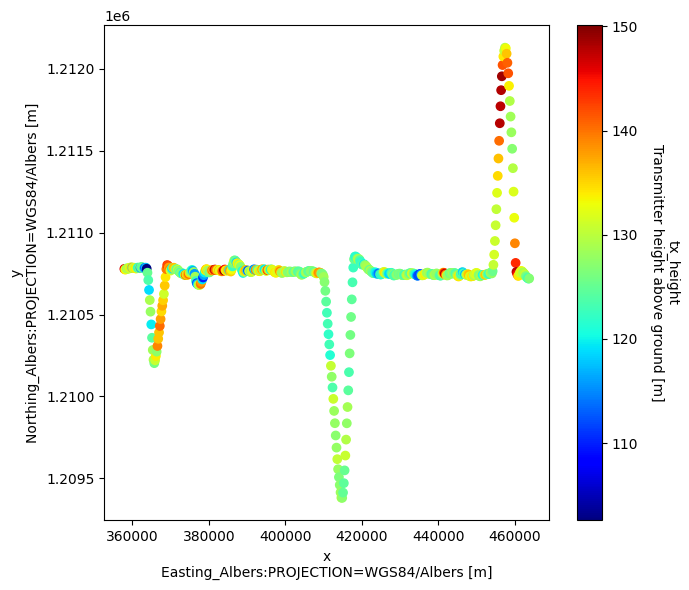

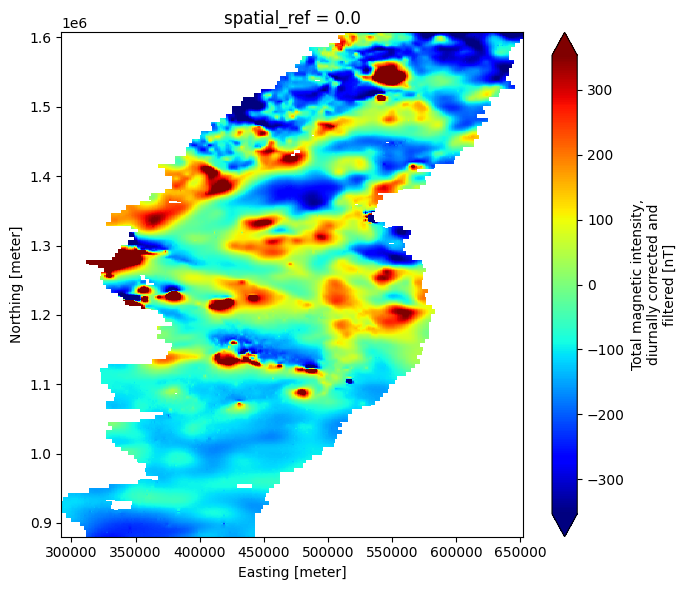

In [13]:
# --------------------------------------------------------------------
# EXERCISE - complete the lines marked with ...
# --------------------------------------------------------------------
plt.figure(figsize=(7, 6))
reopened['data']['raw_data'].gs.scatter(x='x', hue='tx_height', cmap='jet')
plt.tight_layout()

plt.figure(figsize=(7, 6))
reopened['derived_maps/maps']['magnetic_tmi'].plot(cmap='jet', robust=True)
plt.tight_layout()

---
---
## Taking stock

Same eight-step workflow, two very different input formats. What changed was
only how much of the variable metadata came for free:

| | CSV (part 1) | ASEG-GDF (part 2) |
|---|---|---|
| variable names | from the header | from the DFN |
| long names | you write them | from the DFN |
| units | you write them | from the DFN |
| no-data values | you write them | from the DFN |
| which columns are coordinates | you say so | you say so |
| gate times, instrument geometry | a system definition | a system definition |

The two rows at the bottom never come for free, in any format. They are
knowledge about the survey, not about the file, and writing them down once
in a system definition is the most valuable thing in this workshop.

- GSPy documentation: https://doi-usgs.github.io/gspy